In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("../gp_outputs/full_gp_generation.csv")

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_12768\2669945200.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_per_generation = full_df.groupby('generation').apply(


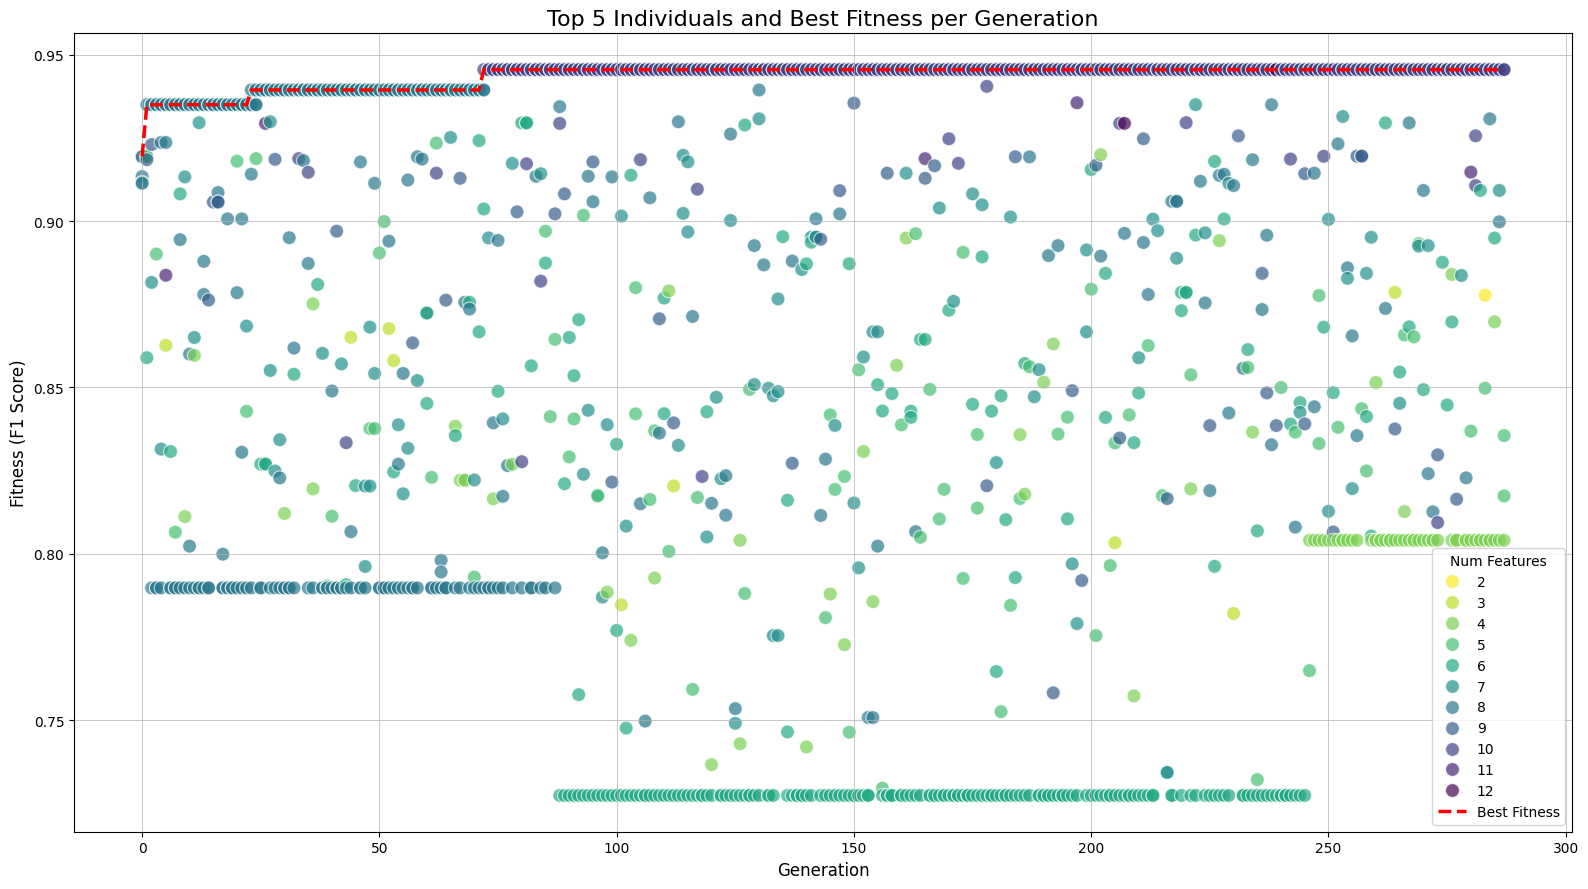

In [ ]:

# 1. Load the full CSV data generated by the experiment
full_df = pd.read_csv("../gp_outputs/full_gp_generation.csv")
# Ensure the 'fitness' column is numeric, in case it was read as a string
full_df['fitness'] = pd.to_numeric(full_df['fitness'])
# 2. Get the Top 5 from Each Generation
#    We group by 'generation' and get the 5 rows with the largest 'fitness'.
top_5_per_generation = full_df.groupby('generation').apply(
    lambda x: x.nlargest(5, 'fitness')
).reset_index(drop=True)
top_5_per_generation['num_features'] = top_5_per_generation['phenotype'].str.count("True")
# 3. Get the Single Best from Each Generation (for the red line)
summary_df = full_df.loc[full_df.groupby('generation')['fitness'].idxmax()]
# 4. Create the Complete Visualization
plt.figure(figsize=(16, 9))
# Use seaborn to create the scatter plot of the top 5 individuals
sns.scatterplot(
    data=top_5_per_generation,
    x='generation',
    y='fitness',
    hue='num_features', # Color the dots by the number of features
    palette='viridis_r',# A nice color map
    s=100,              # Size of the dots
    alpha=0.7,          # Make dots slightly transparent
    legend='full'
)
# Use matplotlib to overlay the line plot of the single best fitness
plt.plot(
    summary_df['generation'],
    summary_df['fitness'],
    color='red',
    linestyle='--',
    linewidth=2.5,
    label='Best Fitness'
)
plt.title('Top 5 Individuals and Best Fitness per Generation', fontsize=16)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness (F1 Score)', fontsize=12)
plt.legend(title='Num Features')
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()
